## Setup

In [1]:
from gut_former.utils.fig_style import apply_style

apply_style(font_family="DejaVu Serif", base_font_size=16)

In [2]:
import numpy as np
import pandas as pd
from scipy import stats

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import KFold, GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score

In [3]:
from gut_former.utils.project_paths import find_data_path, find_figures_path

data_path = find_data_path()
output_path = find_data_path().parent / "output"
figures_path = find_figures_path()
figures_path.mkdir(parents=True, exist_ok=True)

## Read Data

In [4]:
latent_df = pd.read_csv(f"{output_path}/latent_sample.csv", index_col=0)

metadata = (
    pd.read_csv(f"{data_path}/metadata_sample.csv", low_memory=False)
    .query("sample_id in @latent_df.index")
    .sort_index()
)
metadata["health_status"] = (metadata["study_condition"] != "control").astype(int)

age_dict           = dict(zip(metadata.sample_id, metadata.age))
bmi_dict           = dict(zip(metadata.sample_id, metadata.BMI))
health_status_dict = dict(zip(metadata.sample_id, metadata.health_status))

# Colours per regression group
palette = {"Healthy": "orange", "Sick": "grey", "children": "#12277a",
           "Children": "#12277a", "Adults": "#4C72B0", "BMI": "#f266c6"}
line_colors = {"Healthy": "orange", "Sick": "grey", "children": "#861362",
               "Children": "#861362", "Adults": "#444444", "BMI": "#861362"}

print(f"latent: {latent_df.shape} | age non-null: {metadata.age.notna().sum()} "
      f"| BMI non-null: {metadata.BMI.notna().sum()}")

latent: (128, 64) | age non-null: 101 | BMI non-null: 99


/var/folders/6p/lf2mjrln3bn2l0f1tywc4j580000gn/T/ipykernel_25299/2913977886.py:8: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  metadata["health_status"] = (metadata["study_condition"] != "control").astype(int)


## Helpers

In [5]:
LATENT_COLS = list(latent_df.columns)


def run_rf_reg(X, y):
    """Cross-validated Random Forest regression; returns preds, truth, r, R2 per fold."""
    # GUARD (G2): cap KFold splits so each test fold keeps >=2 points (needed by
    # pearsonr / r2). KFold(n_splits=7) would raise on tiny subsets; use
    # min(7, len // 2) so folds never shrink below 2 samples.
    n_splits = min(7, len(X) // 2)

    all_preds, all_true, corr_list, r2_list = [], [], [], []
    param_grid = {"n_estimators": [100, 300], "max_depth": [None, 10, 20]}
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)

    for tr, te in kf.split(X):
        X_tr, X_te, y_tr, y_te = X.iloc[tr], X.iloc[te], y.iloc[tr], y.iloc[te]
        gs = GridSearchCV(RandomForestRegressor(random_state=42), param_grid,
                          cv=3, scoring="r2", n_jobs=-1)
        gs.fit(X_tr, y_tr)
        y_pred = gs.best_estimator_.predict(X_te)
        y_pred[y_pred < 0] = 0

        all_preds.extend(y_pred)
        all_true.extend(y_te)
        r2_list.append(r2_score(y_te, y_pred))
        # GUARD (G3): a Pearson correlation needs >=2 points. With tiny test folds
        # pearsonr() returns NaN or errors, so only record it when the fold is big
        # enough instead of letting it break the run.
        if len(y_te) >= 2:
            corr_list.append(stats.pearsonr(y_pred, y_te)[0])

    return np.array(all_preds), np.array(all_true), corr_list, r2_list


def regress_or_skip(X, y, label):
    # GUARD (G1): skip a regression panel when its subset is empty or too small for
    # a 2-fold CV. On the sample dataset there are 0 children, so building X/y and
    # calling KFold would crash on empty data - skip with a message instead.
    if len(X) < 4:
        print(f"{label}: only {len(X)} samples - skipping regression panel.")
        return None
    return run_rf_reg(X, y)


def prepare_age_data(df, status):
    """Filter by health status, then subsample up to 100 per age decade."""
    df = df[df["health_status"].isin(status)].dropna(subset=["age"])
    idx = []
    for lo in range(0, 100, 10):
        grp = df.query("age >= @lo and age < @lo + 10")
        idx += grp.sample(min(100, len(grp)), random_state=42).index.tolist()
    df = df.loc[idx]
    return df[LATENT_COLS], df["age"]


def prep_simple(df, target):
    return df[LATENT_COLS], df[target]


def plot_single_reg(res, label, xlabel, ylabel, fname):
    y_pred, y_true, corr, r2 = res
    fig, ax = plt.subplots(figsize=(6, 5))
    sns.regplot(x=y_true, y=y_pred, color=palette[label],
                line_kws={"lw": 2.5, "color": line_colors[label]},
                scatter_kws={"s": 25, "alpha": 0.5, "edgecolor": "none"}, ax=ax)
    # F1 fix: fixed text position (original code reused a stale loop variable `i`).
    ax.text(0.05, 0.95, f"{label}\nr = {np.nanmean(corr):.2f}, R² = {np.nanmean(r2):.2f}",
            transform=ax.transAxes, fontsize=12, verticalalignment="top", color=palette[label],
            bbox=dict(boxstyle="round,pad=0.3", facecolor="white",
                      edgecolor=palette[label], alpha=0.9, linewidth=0.8))
    ax.set_xlabel(xlabel, fontsize=14, weight="bold")
    ax.set_ylabel(ylabel, fontsize=14, weight="bold")
    ax.grid(lw=0.3, axis="both", linestyle=":", alpha=0.6)
    ax.spines[["top", "right"]].set_visible(False)
    plt.tight_layout()
    plt.savefig(f"{figures_path}/{fname}", dpi=300, bbox_inches="tight")
    plt.show()

# Supplementary Figure 5A - age distributions

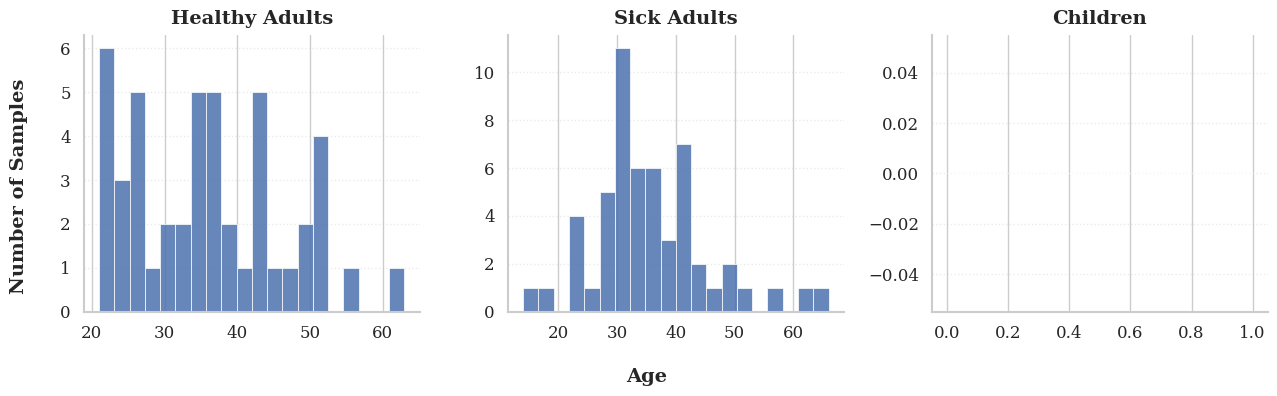

In [6]:
FSIZE, color = 14, "#4C72B0"
queries = [
    ("study_condition == 'control' and age > 10", "Healthy Adults"),
    ("study_condition != 'control' and age > 10", "Sick Adults"),
    ("age < 10", "Children"),
]

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, (query, title) in zip(axes, queries):
    ax.hist(metadata.query(query)["age"], bins=20, color=color,
            edgecolor="white", linewidth=0.6, alpha=0.85)
    ax.set_title(title, fontsize=FSIZE, fontweight="bold", pad=8)
    ax.grid(axis="y", linestyle=":", alpha=0.4)
    ax.spines[["top", "right"]].set_visible(False)

fig.text(0.5, 0.01, "Age", ha="center", fontsize=FSIZE, fontweight="bold")
fig.text(0.01, 0.5, "Number of Samples", va="center", rotation="vertical",
         fontsize=FSIZE, fontweight="bold")
plt.tight_layout(rect=[0.03, 0.05, 1, 1])
plt.savefig(f"{figures_path}/sFig5A.png", dpi=300, bbox_inches="tight")
plt.show()

# Supplementary Figure 5B - BMI distribution

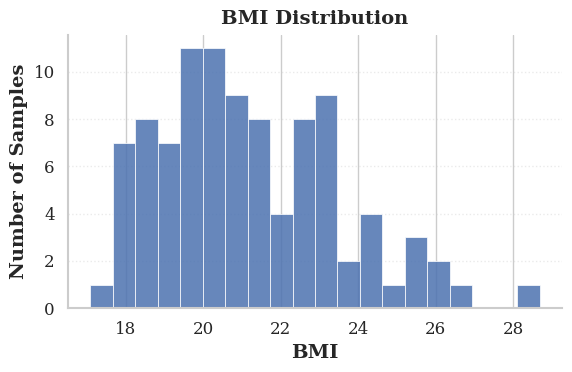

In [7]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(metadata.query("age > 20")["BMI"], bins=20, color="#4C72B0",
        edgecolor="white", linewidth=0.6, alpha=0.85)
ax.set_title("BMI Distribution", fontsize=14, fontweight="bold", pad=8)
ax.set_xlabel("BMI", fontsize=14, fontweight="bold")
ax.set_ylabel("Number of Samples", fontsize=14, fontweight="bold")
ax.grid(axis="y", linestyle=":", alpha=0.4)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig(f"{figures_path}/sFig5B.png", dpi=300, bbox_inches="tight")
plt.show()

# Figure 5A - age regression (Healthy vs Sick)

In [8]:
z_age = latent_df.assign(
    age=latent_df.index.map(age_dict),
    health_status=latent_df.index.map(health_status_dict),
)

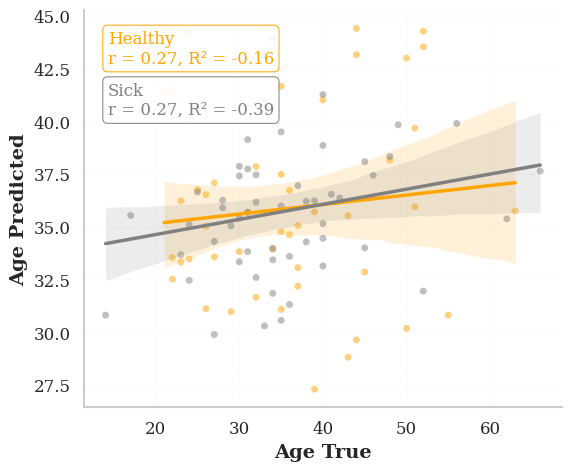

In [9]:
X_h, y_h = prepare_age_data(z_age[z_age["age"] > 10], [0])
X_s, y_s = prepare_age_data(z_age[z_age["age"] > 10], [1])
res_h = regress_or_skip(X_h, y_h, "Healthy adults")
res_s = regress_or_skip(X_s, y_s, "Sick adults")

fig, ax = plt.subplots(figsize=(6, 5))
for i, (label, res) in enumerate([("Healthy", res_h), ("Sick", res_s)]):
    if res is None:
        continue
    y_pred, y_true, corr, r2 = res
    sns.regplot(x=y_true, y=y_pred, color=palette[label],
                line_kws={"lw": 2.5, "color": line_colors[label]},
                scatter_kws={"s": 25, "alpha": 0.5, "edgecolor": "none"}, ax=ax)
    ax.text(0.05, 0.95 - i * 0.13,
            f"{label}\nr = {np.nanmean(corr):.2f}, R² = {np.nanmean(r2):.2f}",
            transform=ax.transAxes, fontsize=12, verticalalignment="top", color=palette[label],
            bbox=dict(boxstyle="round,pad=0.3", facecolor="white",
                      edgecolor=palette[label], alpha=0.9, linewidth=0.8))

ax.set_xlabel("Age True", fontsize=14, weight="bold")
ax.set_ylabel("Age Predicted", fontsize=14, weight="bold")
ax.grid(lw=0.3, axis="both", linestyle=":", alpha=0.6)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig(f"{figures_path}/Fig5A.png", dpi=300, bbox_inches="tight")
plt.show()

# Figure 5B - age regression (Children)

In [10]:
X_c, y_c = prepare_age_data(z_age[z_age["age"] <= 10], [0, 1])
res_c = regress_or_skip(X_c, y_c, "Children")
if res_c is not None:
    plot_single_reg(res_c, "children", "Age True", "Age Predicted", "Fig5B.png")
else:
    print("Fig5B skipped - no children in this dataset.")

Children: only 0 samples - skipping regression panel.
Fig5B skipped - no children in this dataset.


# Figure 5C - age regression (Adults vs Children)

Children: only 0 samples - skipping regression panel.


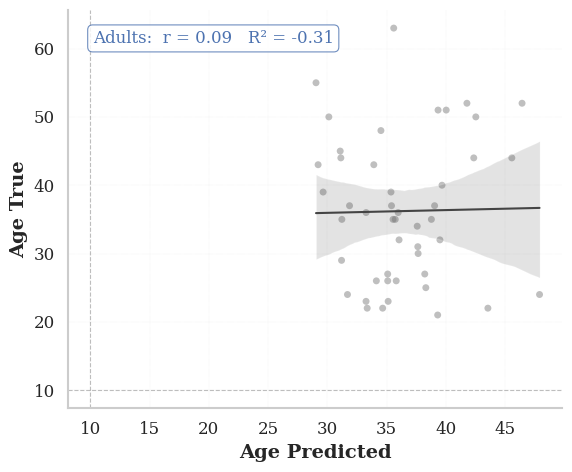

In [11]:
# F2 fix: this dual (adults vs children) panel is Fig5C, not figures/Fig4/Fig4F.
z_h = z_age[z_age["health_status"] == 0]
res_adults   = regress_or_skip(*prep_simple(z_h[z_h["age"] > 10], "age"), "Adults")
res_children = regress_or_skip(*prep_simple(z_h[z_h["age"] <= 10], "age"), "Children")

results = {k: v for k, v in {"Adults": res_adults, "Children": res_children}.items() if v is not None}

if results:
    all_pred = np.concatenate([r[0] for r in results.values()])
    all_true = np.concatenate([r[1] for r in results.values()])
    fig, ax = plt.subplots(figsize=(6, 5))
    sns.regplot(x=all_pred, y=all_true, color="grey",
                line_kws={"lw": 1.5, "color": "#444444"},
                scatter_kws={"s": 25, "alpha": 0.5, "edgecolor": "none"}, ax=ax)
    for i, (label, (yp, yt, corr, r2)) in enumerate(results.items()):
        ax.text(0.05, 0.95 - i * 0.13,
                f"{label}:  r = {np.nanmean(corr):.2f}   R² = {np.nanmean(r2):.2f}",
                transform=ax.transAxes, fontsize=12, verticalalignment="top", color=palette[label],
                bbox=dict(boxstyle="round,pad=0.3", facecolor="white",
                          edgecolor=palette[label], alpha=0.8, linewidth=0.8))
    ax.axhline(10, color="gray", lw=0.8, linestyle="--", alpha=0.5)
    ax.axvline(10, color="gray", lw=0.8, linestyle="--", alpha=0.5)
    ax.set_xlabel("Age Predicted", fontsize=14, weight="bold")
    ax.set_ylabel("Age True", fontsize=14, weight="bold")
    ax.grid(lw=0.3, axis="both", linestyle=":", alpha=0.6)
    ax.spines[["top", "right"]].set_visible(False)
    plt.tight_layout()
    plt.savefig(f"{figures_path}/Fig5C.png", dpi=300, bbox_inches="tight")
    plt.show()
else:
    print("Fig5C skipped - no qualifying subsets.")

# Figure 5D - BMI regression (Adults)

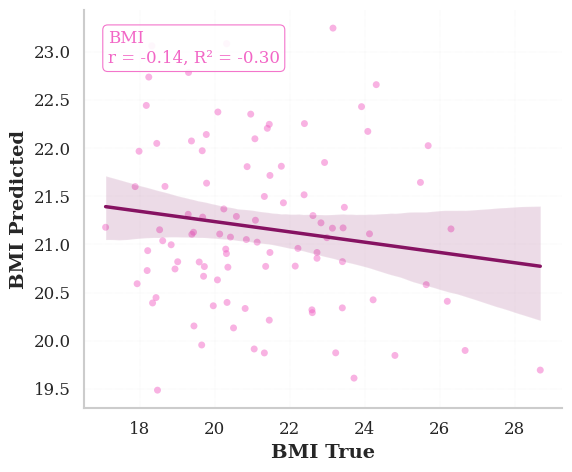

In [12]:
z_bmi = latent_df.assign(
    bmi=latent_df.index.map(bmi_dict),
    age=latent_df.index.map(age_dict),
).dropna(subset=["bmi"])
z_bmi = z_bmi[z_bmi["age"] > 20]

X_bmi, y_bmi = z_bmi[LATENT_COLS], z_bmi["bmi"]
res_bmi = regress_or_skip(X_bmi, y_bmi, "BMI adults")
if res_bmi is not None:
    plot_single_reg(res_bmi, "BMI", "BMI True", "BMI Predicted", "Fig5D.png")
else:
    print("Fig5D skipped - too few BMI samples.")